In [1]:
import allel
print("allel:",allel.__version__)
import numpy as np
import scipy as sp
print("numpy:",np.__version__)

import re
import sys

from tabulate import tabulate
import pandas as pd

import tabix
import random

from math import isnan, isfinite

allel: 1.3.5
numpy: 1.21.6


In [2]:
from plotnine import *

In [10]:
vcffilestr='resources/Aaeg1200g/aegy.wgs.aaa.aaf.norep5-30x.ac10.thinrand01.phased.chr{chrom}.vcf.gz'
metafile='resources/meta_Aaeg1kg_spp.txt'
invfile='resources/lostruct_inversions_table.txt'


In [19]:
#meta = pd.read_csv(metafile, sep='\t')
meta = np.genfromtxt(metafile,delimiter='\t',names=True,dtype=None,encoding='utf-8')

invs = pd.read_csv(invfile, sep='\t')


chrlens = {1:310827022,
          2:474425716,
          3:409777670}


In [55]:
def getr2tab(country,bsize,chrom):
    column='country'
    pop1samps = meta['sample'][meta[column]==country]

    callset1 = allel.read_vcf(vcffile, samples=pop1samps, fields='*')
    #gtpop1 = allel.GenotypeArray(callset1['calldata/GT'])
    #acpop1 = gtpop1.count_alleles()
    altcounts = callset1['calldata/GT'][:,:,0] + callset1['calldata/GT'][:,:,1]

    #remove all non-variant / all-het sites / singletons
    hasvar = np.logical_not(np.any(np.vstack([np.all(altcounts==2,1),
               np.all(altcounts==1,1),
               np.all(altcounts==0,1),
               np.sum(altcounts,1)==1]),0))

    goodposn = callset1['variants/POS'][hasvar]
    goodcounts = altcounts[hasvar,:]

    r2, r2wins, r2n  = allel.windowed_r_squared(goodposn, goodcounts, 
                                                size=bsize, start=0, 
                                                stop=chrlens[chrom], step=bsize)

    r2ctab = pd.DataFrame({
         "country":[country]*len(r2),
         "chrom":[chrom]*len(r2),
         "start":r2wins[:,0],
         "end":r2wins[:,1],
         "r2samp":r2})
    return r2ctab


In [56]:
r2ctab = getr2tab(country,100000,1)

In [57]:
r2ctab

,country,chrom,start,end,r2samp
0,Angola,1,0,99999,0.086406
1,Angola,1,100000,199999,0.068871
2,Angola,1,200000,299999,0.080808
3,Angola,1,300000,399999,0.080026
4,Angola,1,400000,499999,0.080026
...,...,...,...,...,...
3104,Angola,1,310400000,310499999,0.054545
3105,Angola,1,310500000,310599999,0.054545
3106,Angola,1,310600000,310699999,0.090000
3107,Angola,1,310700000,310799999,0.074242


In [ ]:

bsize=100000

r2tab = None
for chrom in [1,2,3]:
    vcffile=vcffilestr.format(chrom=chrom)
    for country in np.unique(meta['country']):
        print(country)
        r2ctab = getr2tab(country)
                
        if(r2tab is None):
            r2tab = r2ctab
        else:
            r2tab = r2tab.append(r2ctab)
            

In [ ]:
r2tab.to_csv("all_countries_LD_wins_500kb.txt", sep="\t", quoting=csv.QUOTE_NONE)

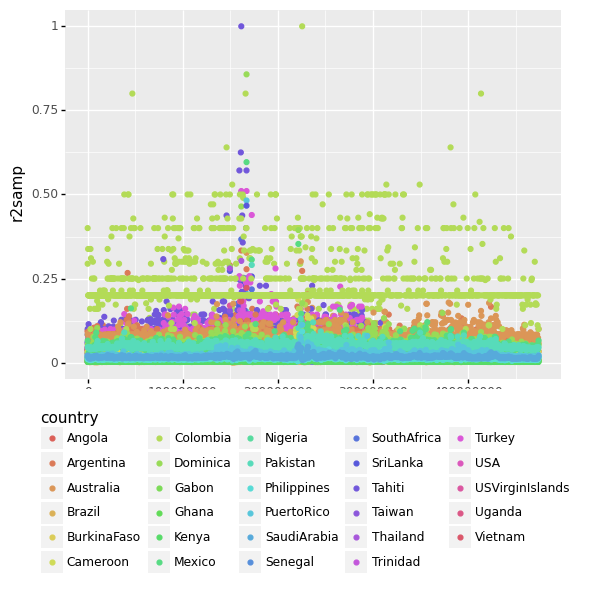

In [24]:
p = ggplot(r2tab,aes(x='start',y='r2samp',color='country')) + \
  geom_point() + \
  theme(legend_position="bottom")
print(p)
